# Hello RNN – character‑level language model (Keras)


In [1]:
# Imports & data preparation
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import keras

In [2]:
# Load a tiny text corpus (Shakespeare excerpt is fine for a demo)
with open("./data/shakespeare.txt", encoding="utf-8") as fp:
    text = fp.read().lower()[:50000]

vocab = sorted(set(text))
char2idx = {c: i for i, c in enumerate(vocab)}
idx2char = np.array(vocab)

In [3]:
SEQUENCE_LENGTH = 40  # length of each training example
STEP = 3  # stride (helps increase data)
sentences = []
next_chars = []

for i in range(0, len(text) - SEQUENCE_LENGTH, STEP):
    sentences.append(text[i : i + SEQUENCE_LENGTH])
    next_chars.append(text[i + SEQUENCE_LENGTH])

X = np.array([[char2idx[c] for c in s] for s in sentences])
y = np.array([char2idx[c] for c in next_chars])

y = keras.utils.to_categorical(y, num_classes=len(vocab))

In [4]:
# Model definition
model = keras.Sequential(
    [
        keras.layers.Embedding(input_dim=len(vocab), output_dim=64),
        keras.layers.LSTM(128, return_sequences=False),
        keras.layers.Dense(len(vocab), activation="softmax"),
    ]
)

model.compile(loss="categorical_crossentropy", optimizer="adam")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
# ▶ Train (few epochs – enough to see loss drop)
history = model.fit(X, y, batch_size=64, epochs=8, validation_split=0.1)

Epoch 1/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 2.8539 - val_loss: 2.4664
Epoch 2/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 2.3277 - val_loss: 2.1738
Epoch 3/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 2.1580 - val_loss: 2.0647
Epoch 4/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 2.0660 - val_loss: 1.9897
Epoch 5/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1.9908 - val_loss: 1.9254
Epoch 6/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1.9222 - val_loss: 1.8790
Epoch 7/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1.8654 - val_loss: 1.8328
Epoch 8/8
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 1.8224 - val_loss: 1.8077


In [33]:
history

,epoch,loss,score
0,0,loss,2.854569
1,1,loss,2.323489
2,2,loss,2.152006
3,3,loss,2.051675
4,4,loss,1.966984
5,5,loss,1.888808
6,6,loss,1.834675
7,7,loss,1.785540
8,0,val_loss,2.450934
9,1,val_loss,2.185816


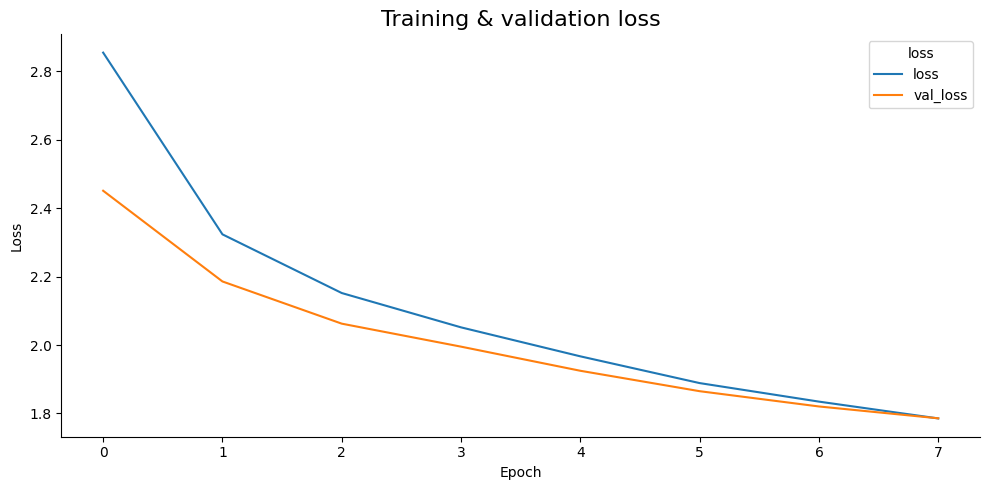

In [ ]:
# Plot loss curves
_, ax = plt.subplots(figsize=(10, 5))

history_df = (
    pd.DataFrame(history.history)
    .reset_index(names="epoch")
    .melt(var_name="loss", value_name="score", id_vars="epoch")
)
sns.lineplot(data=history_df, x="epoch", y="score", hue="loss", ax=ax)
ax.set_title("Training & validation loss", fontsize=16)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

sns.despine()
plt.tight_layout()
plt.show()

In [6]:
def sample_text(seed, length=300, temperature=0.8):
    seed_idx = [char2idx[c] for c in seed.lower()[:SEQUENCE_LENGTH]]
    generated = seed.lower()[:SEQUENCE_LENGTH]

    for _ in range(length):
        x = np.array(seed_idx)[np.newaxis, :]
        preds = model.predict(x, verbose=0)[0]

        # temperature‑scaled sampling
        preds = np.log(preds) / temperature
        exp_preds = np.exp(preds)
        probs = exp_preds / np.sum(exp_preds)
        next_idx = np.random.choice(len(vocab), p=probs)
        next_char = idx2char[next_idx]
        generated += next_char
        seed_idx = seed_idx[1:] + [next_idx]

    return generated


# Actual: Whether 'tis nobler in the mind to suffer. The slings and arrows of outrageous fortune,
print(sample_text("To be, or not to be, that is the question"))

to be, or not to be, that is the questior maches thay,
  to deratt meren corman with dlravedo sondours by lene;
 s eft thet for than the heboage's selde,
  when wilces my and i and dreat tresel'singd are,
  thaud streper ande thace fath but vile,
  where nos beares bemenjens uy o fminsigot,
  what i thee sich bum you lopt houl thy shame,

